<a href="https://colab.research.google.com/github/giovani-gutierrez/animal_shelter_outcomes/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning & Exploratory Data Analysis (EDA)

In [1]:
# library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# set matplotlib & seaborn theme
sns.set_theme(style = 'white')

## Basic Information

In [173]:
shelter = pd.read_csv('https://raw.githubusercontent.com/giovani-gutierrez/animal_shelter_outcomes/refs/heads/main/data/raw.csv')

In [174]:
shelter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10605 entries, 0 to 10604
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AnimalID          10605 non-null  object 
 1   AnimalName        6221 non-null   object 
 2   AnimalType        10605 non-null  object 
 3   PrimaryColor      10605 non-null  object 
 4   SecondaryColor    4241 non-null   object 
 5   PrimaryBreed      10605 non-null  object 
 6   Sex               10605 non-null  object 
 7   DOB               8014 non-null   object 
 8   Age               8014 non-null   float64
 9   IntakeDate        10605 non-null  object 
 10  IntakeCondition   10605 non-null  object 
 11  IntakeType        10605 non-null  object 
 12  IntakeSubtype     10429 non-null  object 
 13  IntakeReason      415 non-null    object 
 14  OutcomeDate       10547 non-null  object 
 15  OutcomeType       10561 non-null  object 
 16  OutcomeSubtype    0 non-null      float6

We can already assume that some of the columns have high cardinality just by their names. For now, we will remove these columns to build a simple baseline model. We will also remove any columns that have a large number of missing values or that we do not think will be relevant in our model. Later on, we will explore the use of categorical encodings for these high-cardinality columns.

In [175]:
shelter['IntakeDate'] = pd.to_datetime(shelter['IntakeDate'])

In [176]:
shelter['OutcomeDate'] = pd.to_datetime(shelter['OutcomeDate'])

In [177]:
for col in shelter.columns:
    print(f'{col}: {shelter[col].nunique()}')

AnimalID: 10108
AnimalName: 3083
AnimalType: 5
PrimaryColor: 49
SecondaryColor: 29
PrimaryBreed: 190
Sex: 5
DOB: 2067
Age: 22
IntakeDate: 364
IntakeCondition: 12
IntakeType: 6
IntakeSubtype: 19
IntakeReason: 26
OutcomeDate: 509
OutcomeType: 9
OutcomeSubtype: 0
OutcomeCondition: 11
Crossing: 5721
Jurisdiction: 15
LastUpdate: 529


In [178]:
shelter = shelter.sort_values(by  = ['AnimalID', 'LastUpdate']).reset_index(drop = True)

In [179]:
shelter = shelter.drop_duplicates(subset = ['AnimalID', 'OutcomeDate', 'Crossing'], keep = 'last', ignore_index = True)

In [180]:
shelter

,AnimalID,AnimalName,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,DOB,Age,IntakeDate,...,IntakeType,IntakeSubtype,IntakeReason,OutcomeDate,OutcomeType,OutcomeSubtype,OutcomeCondition,Crossing,Jurisdiction,LastUpdate
0,A0075579,BAILEY,DOG,BLACK,RED,LABRADOR RETR,SPAYED,1994-01-16,30.0,2024-10-15,...,STRAY,OTC,NaN,2024-10-15,RTO,NaN,MED R,SENTER RD X TULLY RD,SAN JOSE,2024-10-15
1,A0533827,PATCHES,DOG,TRICOLOR,BLACK,PARSON RUSS TER,NEUTERED,2006-02-06,18.0,2024-08-28,...,EUTH REQ,NaN,NaN,2024-08-28,RTO,NaN,MED SEV,NaN,SANTA CLARA,2024-08-28
2,A0569573,SHALE,CAT,BLACK,NaN,DOMESTIC SH,SPAYED,2007-10-12,16.0,2024-09-25,...,STRAY,OTC,NaN,2024-09-25,EUTH,NaN,MED SEV,1600 BLOCK ALMADEN RD,SAN JOSE,2024-09-25
3,A0608333,BLACK,CAT,TORBI-BRN,NaN,DOMESTIC SH,SPAYED,2008-05-05,16.0,2024-08-31,...,STRAY,OTC,NaN,2024-09-03,RTF,NaN,FERAL,RIVER VIEW DR,SAN JOSE,2024-09-03
4,A0636780,SPONGIE,DOG,FAWN,NaN,POODLE MIN,NEUTERED,NaN,NaN,2024-07-22,...,STRAY,OTC,NaN,2024-07-22,RTO,NaN,MED SEV,SNELL AVE,SAN JOSE,2024-08-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10574,A1399686,OLIVE,PUPPY,TAN,NaN,LABRADOR RETR,FEMALE,2024-11-26,0.0,2025-03-12,...,STRAY,OTC,NaN,2025-03-24,RESCUE,NaN,HEALTHY,N 20TH X E JULIAN ST,SAN JOSE,2025-12-05
10575,A1399688,WALTER,CAT,GRAY,WHITE,DOMESTIC SH,NEUTERED,2022-11-26,2.0,2024-12-07,...,STRAY,OTC,IP ADOPT,2024-12-13,RTF,NaN,FERAL,S 10TH ST,SAN JOSE,2024-12-13
10576,A1400316,ALLY CAT,KITTEN,WHITE,BLACK,DOMESTIC SH,SPAYED,2024-10-15,0.0,2024-11-15,...,STRAY,OTC,NaN,2024-11-24,ADOPTION,NaN,HEALTHY,ALMADEN EXPY,SAN JOSE,2024-11-24
10577,A1400331,BELLA,DOG,BLACK,NaN,DOBERMAN PINSCH,SPAYED,2021-12-12,3.0,2025-04-21,...,CONFISCATE,POLICE,NaN,2025-05-03,RTO,NaN,NaN,NaN,SAN JOSE,2025-05-03


In [181]:
for col in shelter.columns:
    print(f'{col}: {shelter[col].nunique()}')

AnimalID: 10108
AnimalName: 3083
AnimalType: 5
PrimaryColor: 49
SecondaryColor: 29
PrimaryBreed: 190
Sex: 5
DOB: 2067
Age: 22
IntakeDate: 364
IntakeCondition: 12
IntakeType: 6
IntakeSubtype: 19
IntakeReason: 26
OutcomeDate: 509
OutcomeType: 9
OutcomeSubtype: 0
OutcomeCondition: 11
Crossing: 5721
Jurisdiction: 15
LastUpdate: 529


In [182]:
cols_to_remove = [
    'PrimaryColor', 'SecondaryColor', 'PrimaryBreed', 'DOB', 'Age',
    'IntakeSubtype', 'IntakeReason', 'OutcomeDate', 'OutcomeSubtype',
    'OutcomeCondition', 'Crossing', 'Jurisdiction', 'LastUpdate'
]

shelter = shelter.drop(columns = cols_to_remove)

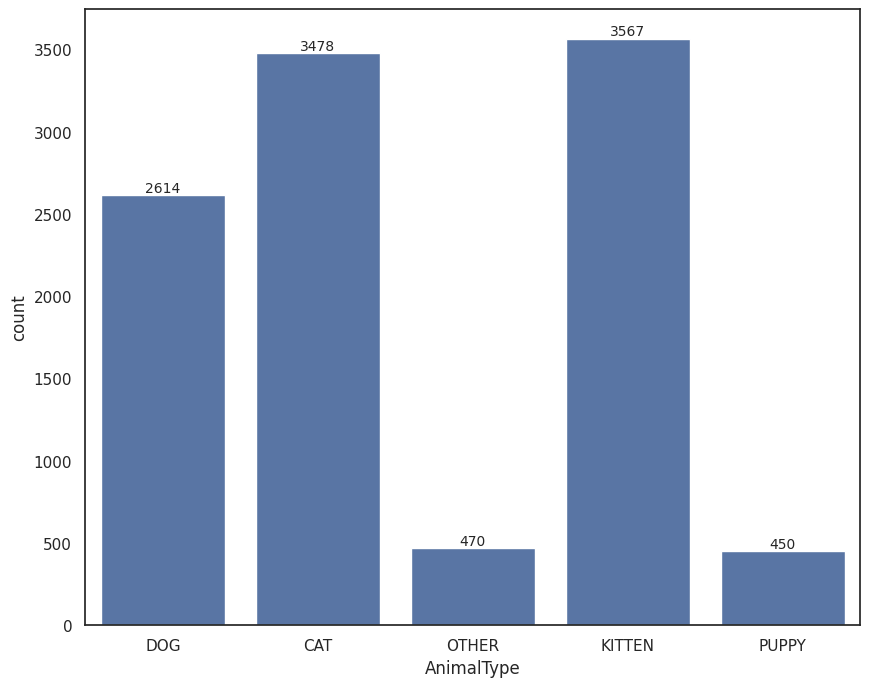

In [183]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.countplot(data = shelter, x = 'AnimalType', ax = ax)
ax.bar_label(ax.containers[0], fontsize=10);

plt.show()

In [184]:
shelter = shelter[shelter['AnimalType'] != 'OTHER']

shelter['BabyAnimal'] = shelter['AnimalType'].isin(['KITTEN', 'PUPPY'])
shelter['AnimalType'] = shelter['AnimalType'].replace({'KITTEN': 'CAT', 'PUPPY': 'DOG'})

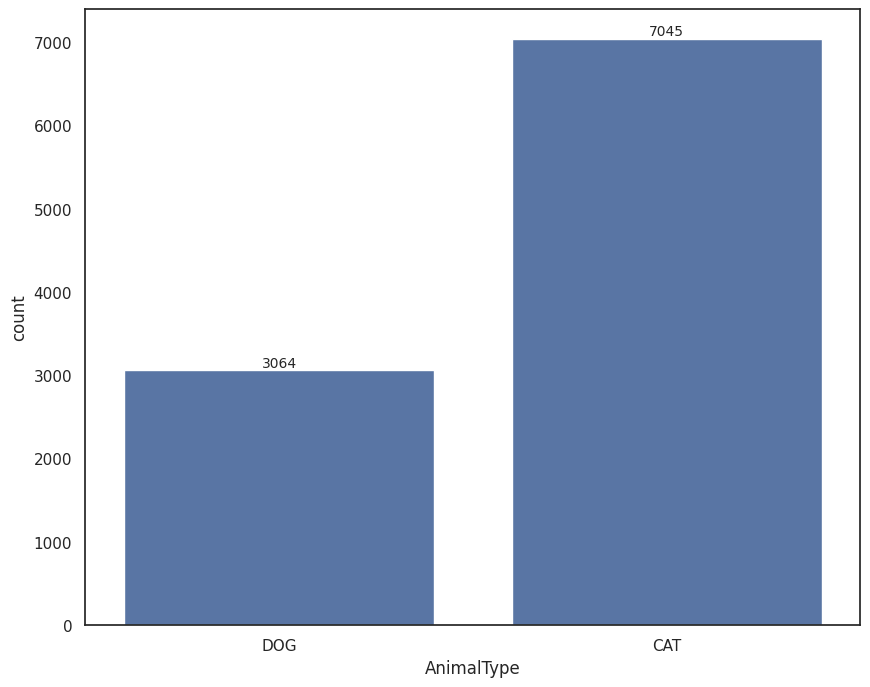

In [185]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.countplot(data = shelter, x = 'AnimalType', ax = ax)
ax.bar_label(ax.containers[0], fontsize = 10);

plt.show()

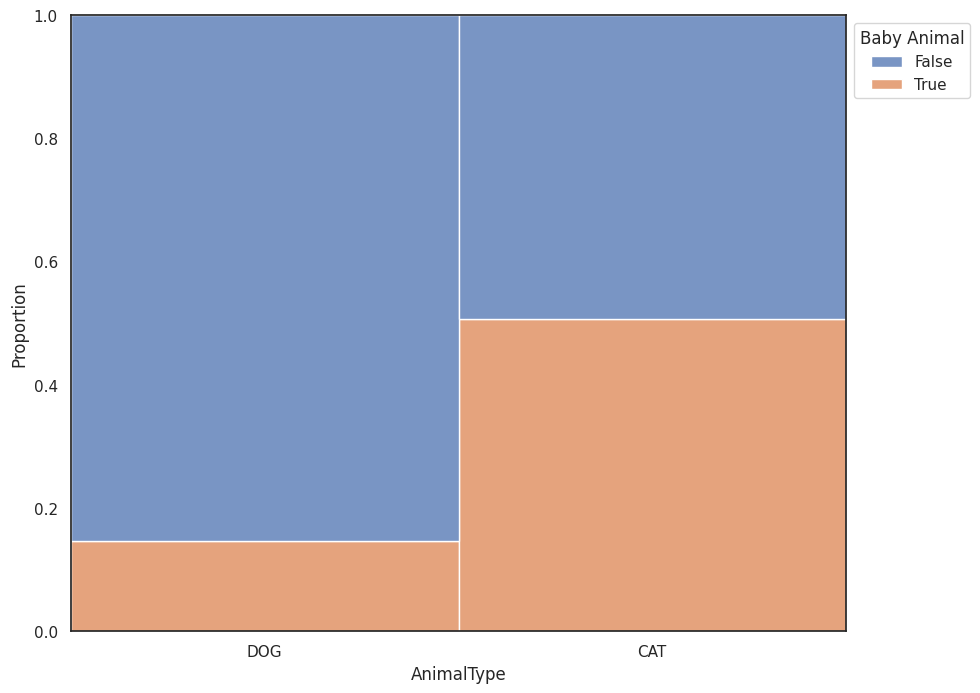

In [186]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.histplot(
    data = shelter,
    x = 'AnimalType',
    hue = 'BabyAnimal',
    stat = 'proportion',
    multiple = 'fill',
    ax = ax
)
sns.move_legend(
    ax,
    'upper left',
    bbox_to_anchor = (1, 1),
    title = 'Baby Animal'
)

plt.show()

In [187]:
shelter['IntakeDate'] = pd.to_datetime(shelter['IntakeDate'])
shelter['IntakeMonthName'] = shelter['IntakeDate'].dt.month_name()
shelter['IntakeMonthNum'] = shelter['IntakeDate'].dt.month

month_to_season = {
    3: 'spring',
    4: 'spring',
    5: 'spring',
    6: 'summer',
    7: 'summer',
    8: 'summer',
    9: 'fall',
    10: 'fall',
    11: 'fall',
    12: 'winter',
    1: 'winter',
    2: 'winter'
}
shelter['IntakeSeason'] = shelter['IntakeMonthNum'].replace(month_to_season)

<Axes: xlabel='count', ylabel='IntakeMonthName'>

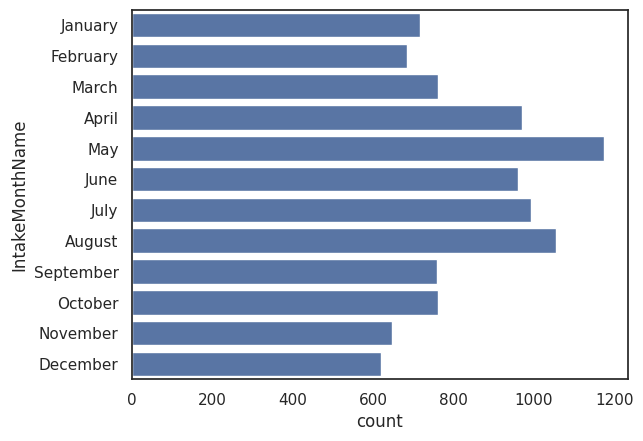

In [188]:
sns.countplot(data = shelter.sort_values(by = ['IntakeMonthNum']), y = 'IntakeMonthName')

<Axes: xlabel='IntakeSeason', ylabel='count'>

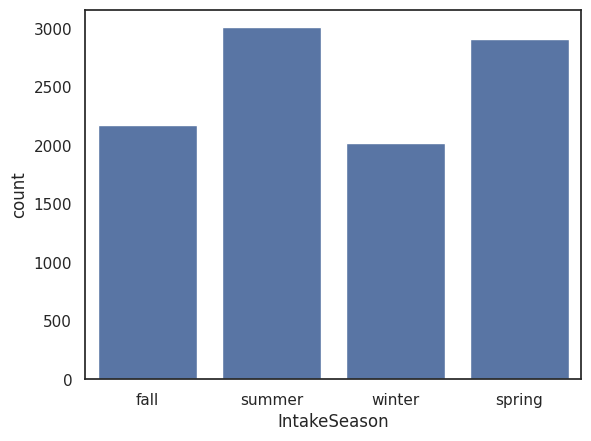

In [189]:
sns.countplot(data = shelter, x = 'IntakeSeason')

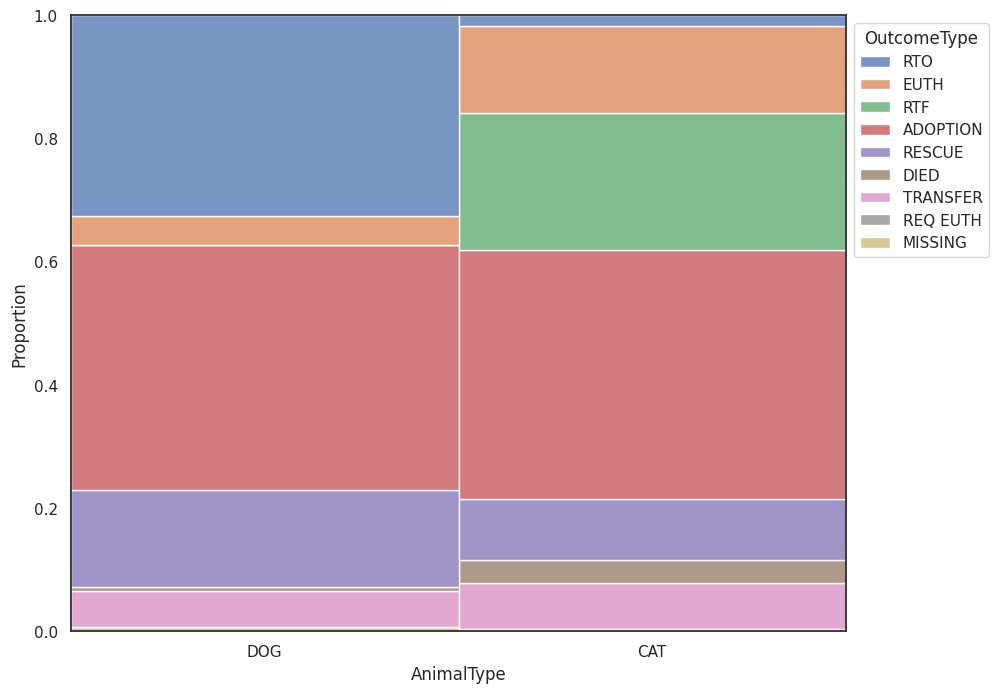

In [190]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.histplot(
    data = shelter,
    x = 'AnimalType',
    hue = 'OutcomeType',
    stat = 'proportion',
    multiple = 'fill',
    ax = ax
)

sns.move_legend(ax, 'upper left', bbox_to_anchor = (1, 1))

plt.show()

In [191]:
neg_outcomes = ['EUTH', 'DIED', 'MISSING', 'REQ EUTH']

shelter['PositiveOutcome'] = ~shelter['OutcomeType'].isin(neg_outcomes)

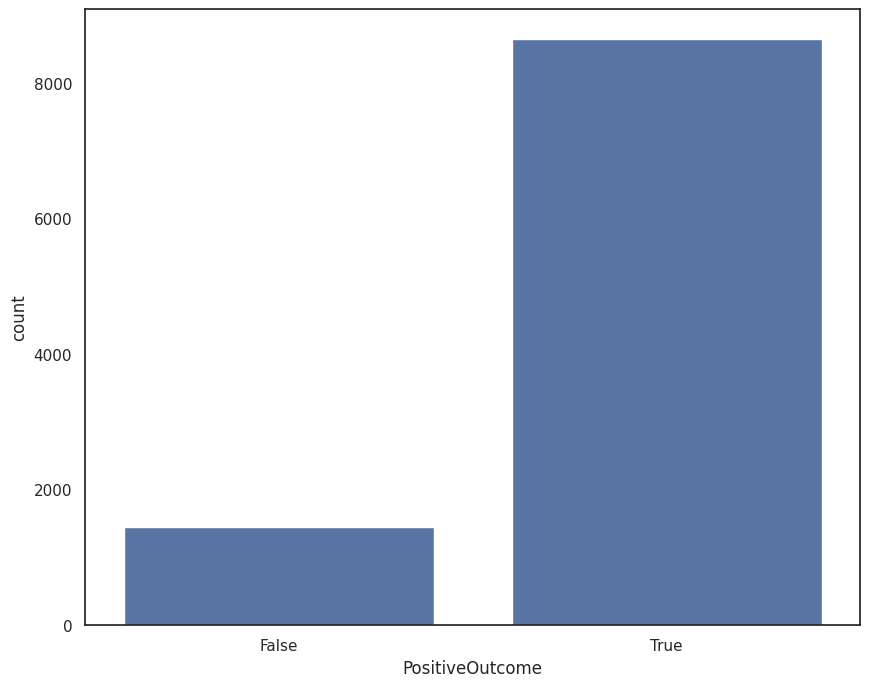

In [192]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.countplot(data = shelter, x = 'PositiveOutcome', ax = ax)

plt.show()

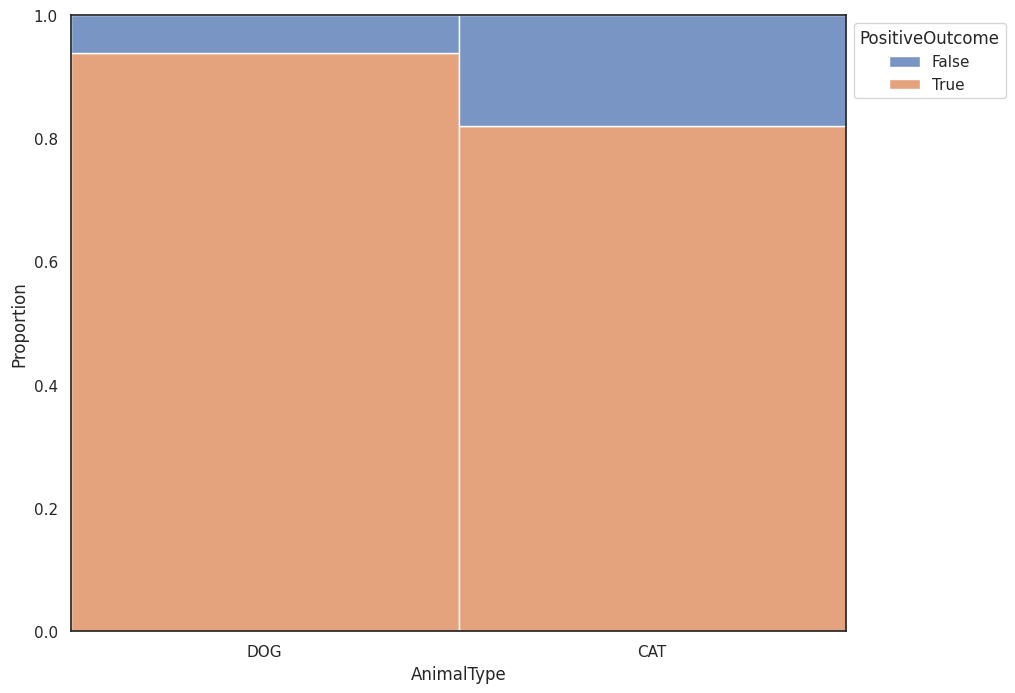

In [193]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.histplot(
    data = shelter,
    x = 'AnimalType',
    hue = 'PositiveOutcome',
    stat = 'proportion',
    multiple = 'fill',
    ax = ax
)
sns.move_legend(ax, 'upper left', bbox_to_anchor = (1, 1))

plt.show()

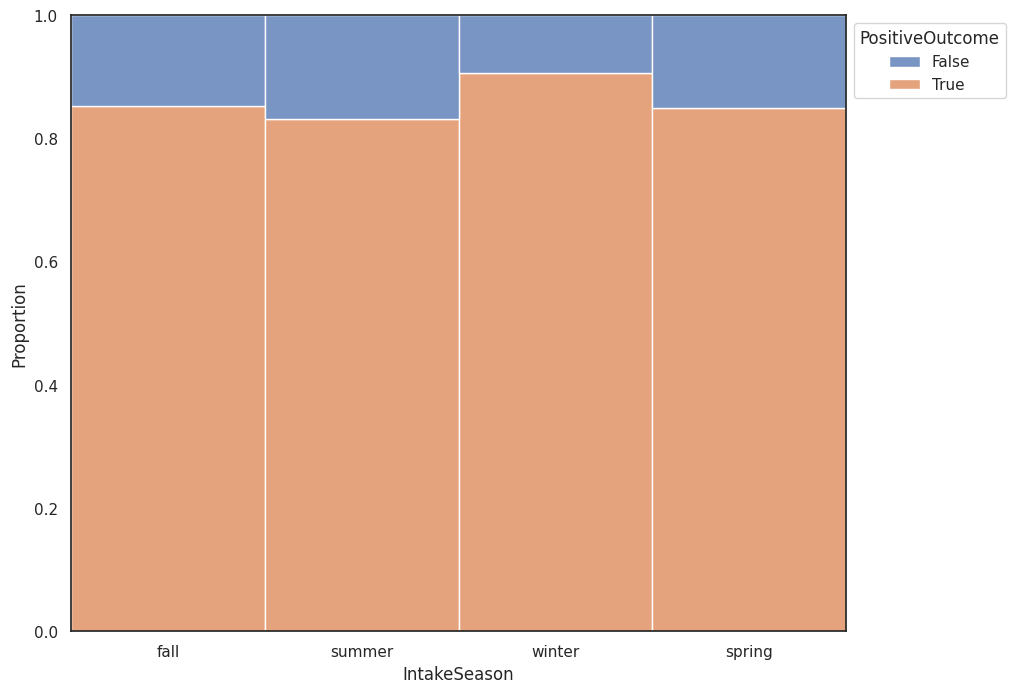

In [194]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.histplot(
    data = shelter,
    x = 'IntakeSeason',
    hue = 'PositiveOutcome',
    stat = 'proportion',
    multiple = 'fill',
    ax = ax
)

sns.move_legend(ax, 'upper left', bbox_to_anchor = (1, 1))

plt.show()

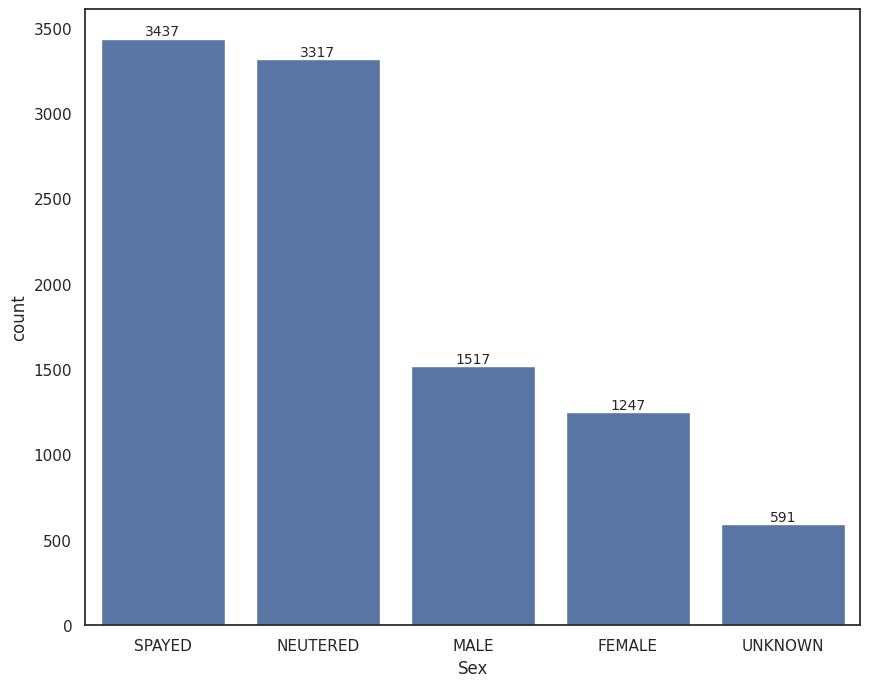

In [195]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.countplot(data = shelter, x = 'Sex', ax = ax)
ax.bar_label(ax.containers[0], fontsize = 10);

plt.show()

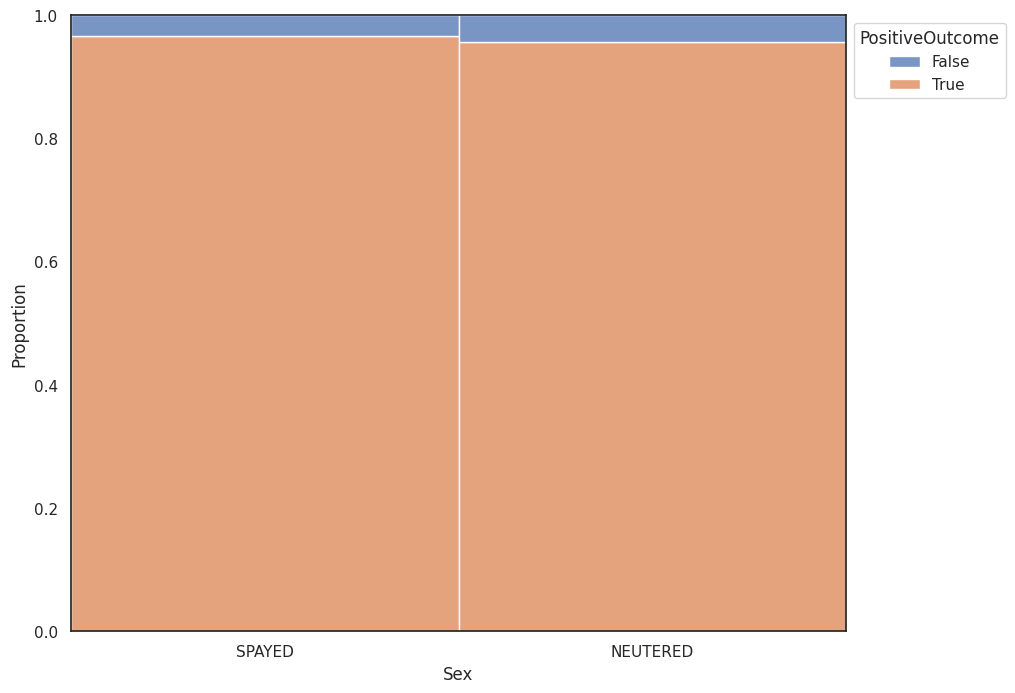

In [196]:
temp = shelter[shelter['Sex'].isin(['SPAYED', 'NEUTERED'])]

fig, ax = plt.subplots(figsize = (10, 8))

sns.histplot(
    data = temp,
    x = 'Sex',
    hue = 'PositiveOutcome',
    stat = 'proportion',
    multiple = 'fill',
    ax = ax
)

sns.move_legend(ax, 'upper left', bbox_to_anchor = (1, 1))

plt.show()

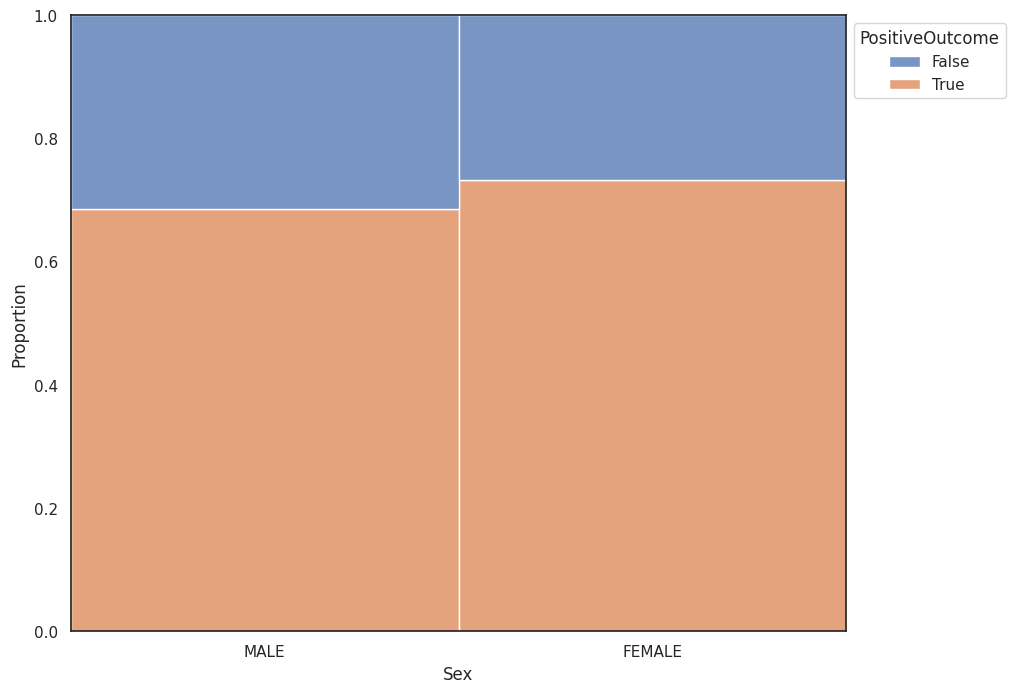

In [197]:
temp = shelter[shelter['Sex'].isin(['MALE', 'FEMALE'])]

fig, ax = plt.subplots(figsize = (10, 8))

sns.histplot(
    data = temp,
    x = 'Sex',
    hue = 'PositiveOutcome',
    stat = 'proportion',
    multiple = 'fill',
    ax = ax
)

sns.move_legend(ax, 'upper left', bbox_to_anchor = (1, 1))

plt.show()

In [198]:
shelter['UnalteredSex'] = shelter['Sex'].replace({'SPAYED': 'FEMALE', 'NEUTERED': 'MALE'})
shelter['Neutered/Spayed'] = shelter['Sex'].isin(['NEUTERED', 'SPAYED'])
shelter = shelter[shelter['Sex'] != 'UNKNOWN']

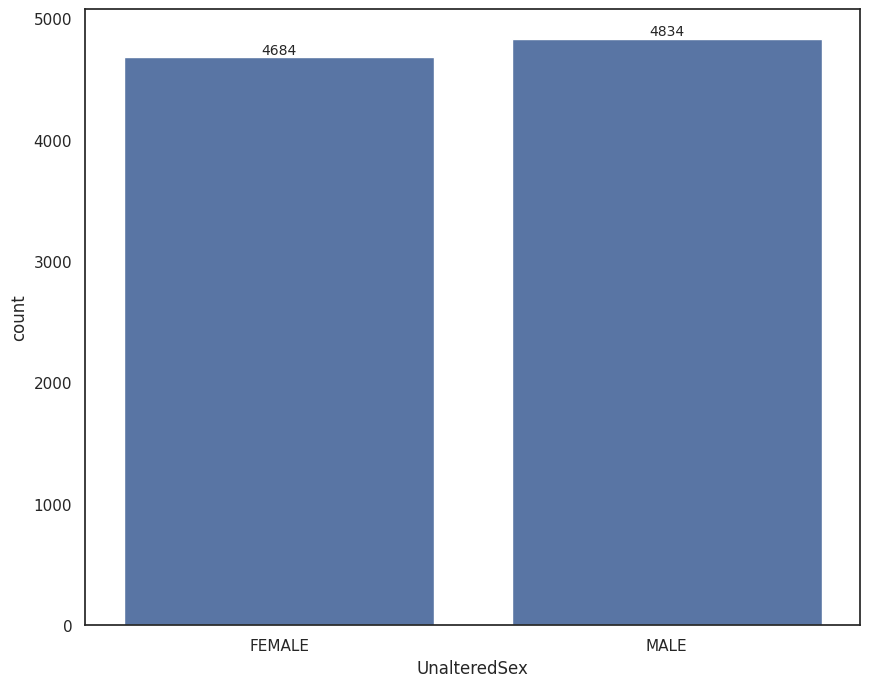

In [199]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.countplot(data = shelter, x = 'UnalteredSex', ax = ax)
ax.bar_label(ax.containers[0], fontsize = 10);

plt.show()

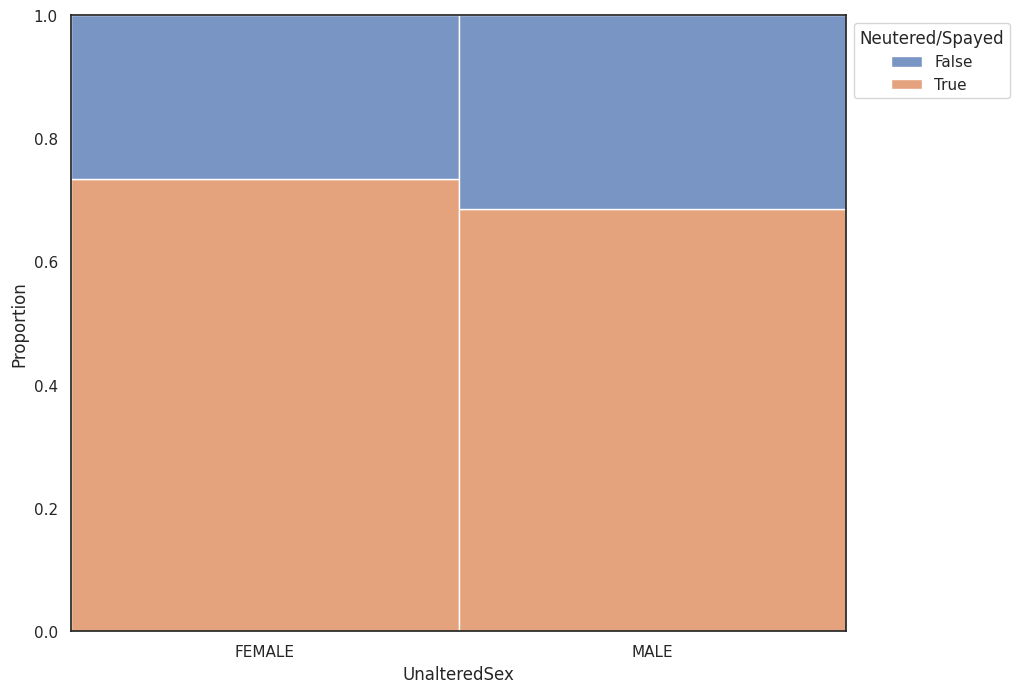

In [200]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.histplot(
    data = shelter,
    x = 'UnalteredSex',
    hue = 'Neutered/Spayed',
    stat = 'proportion',
    multiple = 'fill',
    ax = ax
)
sns.move_legend(ax, 'upper left', bbox_to_anchor = (1, 1))

plt.show()

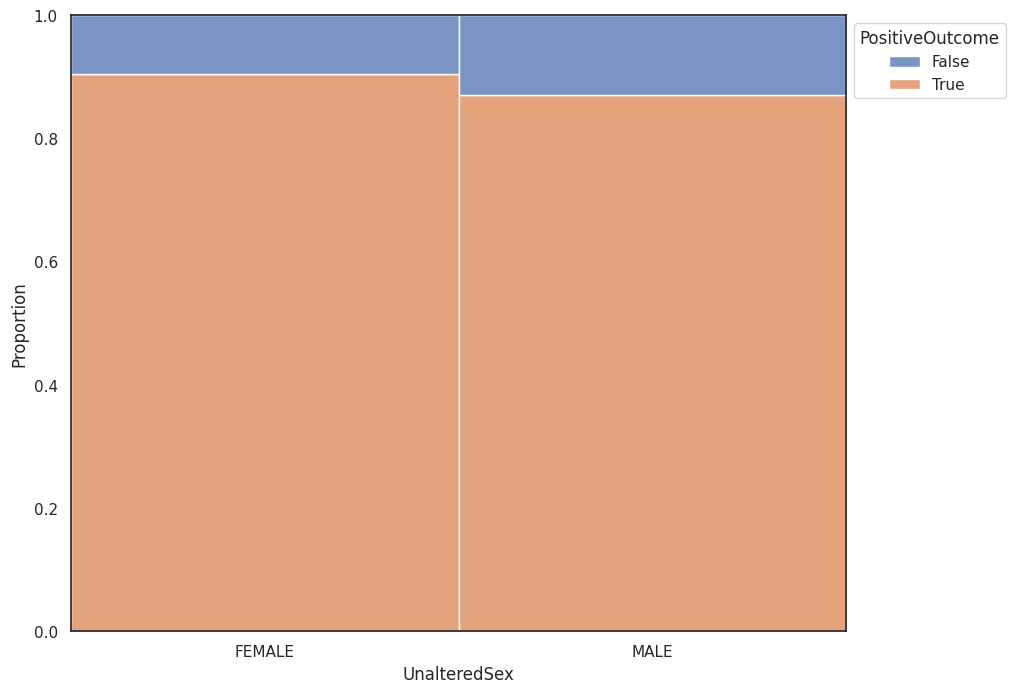

In [201]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.histplot(
    data = shelter,
    x = 'UnalteredSex',
    hue = 'PositiveOutcome',
    stat = 'proportion',
    multiple = 'fill',
    ax = ax
)
sns.move_legend(ax, 'upper left', bbox_to_anchor = (1, 1))

plt.show()

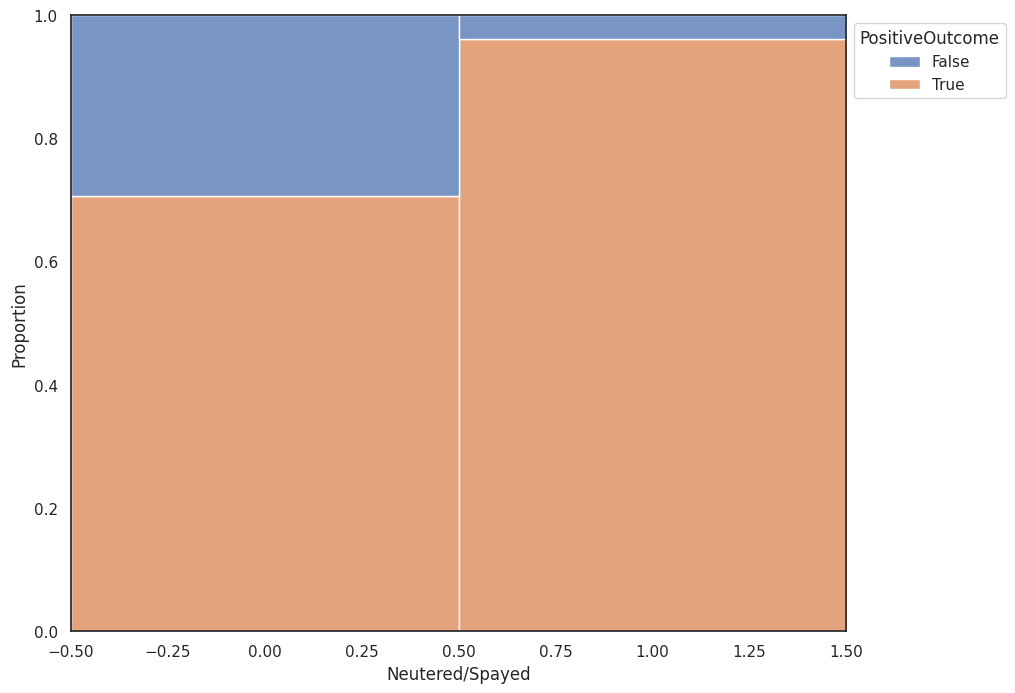

In [202]:
fig, ax = plt.subplots(figsize = (10, 8))

sns.histplot(
    data = shelter,
    x = 'Neutered/Spayed',
    hue = 'PositiveOutcome',
    stat = 'proportion',
    multiple = 'fill',
    discrete = True,
    ax = ax
)
sns.move_legend(ax, 'upper left', bbox_to_anchor = (1, 1))

plt.show()

In [203]:
shelter['Neutered/Spayed'].value_counts()

,count
Neutered/Spayed,
True,6754
False,2764


In [204]:
shelter['IntakeCondition'].value_counts()

,count
IntakeCondition,
HEALTHY,3564
MED R,2733
NURSING,1081
MED SEV,709
PREGNANT,470
BEH M,296
FERAL,270
MED M,132
BEH U,111


## Modeling